In [1]:
!pip install -U peft bitsandbytes transformers accelerate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 835.4/835.4 kB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 91.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.4/846.4 kB 60.1 MB/s eta 0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.29.0
    Uninstalling huggingface_hub-1.29.0:
      Successfully uninstalled huggingface_hub-1.29.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.16.1
    Uninstalling transformers-5.16.1:
      Successfully uninstalled transformers-5.16.1
  Attempting uninstall: accelerate
    Found existing installation: accelerate 1.14.0
    Uninstalling accelerate-1.14.0:
      Successfully uninstalled accelerate-1.14.0
  Attempting uninstall: peft
    Found existing installati

In [2]:
!pip install -U trl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 925.5/925.5 kB 48.8 MB/s eta 0:00:00


In [3]:
!pip install -U torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 71.8 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [4]:

!pip install PyMuPDF

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 82.9 MB/s eta 0:00:00


#### That is the prebuid data set

In [5]:
from datasets import Dataset, load_dataset

In [6]:
dataset = load_dataset("roneneldan/TinyStories", split="train")

README.md:   0%|          | 0.00/1.06k [00:00<?, ?B/s]

data/train-00000-of-00004-2d5a1467fff108(…): reconstructing file:   0%|          |  0.00B /  249MB            

data/train-00000-of-00004-2d5a1467fff108(…): downloading bytes:           |  0.00B            

data/train-00001-of-00004-5852b56a2bd28f(…): reconstructing file:   0%|          |  0.00B /  248MB            

data/train-00001-of-00004-5852b56a2bd28f(…): downloading bytes:           |  0.00B            

...

data/train-00003-of-00004-d243063613e5a0(…): downloading bytes:           |  0.00B            

data/validation-00000-of-00001-869c898b5(…): reconstructing file:   0%|          |  0.00B / 9.99MB            

data/validation-00000-of-00001-869c898b5(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

In [7]:
print(dataset.shape)


(2119719, 1)


In [8]:
dataset[0]

{'text': 'One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.\n\nLily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."\n\nTogether, they shared the needle and sewed the button on Lily\'s shirt. It was not difficult for them because they were sharing and helping each other. After they finished, Lily thanked her mom for sharing the needle and fixing her shirt. They both felt happy because they had shared and worked together.'}

Our own dataset for domain specific finetuning

In [9]:
import fitz

In [10]:
def extract_text_from_pdf(pdf_path):
  text_blocks = []
  with fitz.open(pdf_path) as doc:
    for page in doc:
      text = page.get_text("text").strip()
      if text:
        text_blocks.append(text)
  return text_blocks

In [11]:
pdf_texts = extract_text_from_pdf("/content/medical_ai_paragraphs.pdf")

In [13]:
pdf_texts

['Metformin is one of the most widely prescribed oral antihyperglycemic agents. Its primary\nmechanism of action involves the activation of AMP-activated protein kinase (AMPK), a central\nmetabolic regulator that promotes glucose uptake and fatty acid oxidation while inhibiting hepatic\ngluconeogenesis. Beyond its glycemic control, Metformin has been shown to improve\ncardiovascular outcomes and display anti-inflammatory properties. Recent studies also suggest\npotential anticancer effects through inhibition of the mTOR signaling pathway and suppression of\ntumor angiogenesis.\nClinical trials have demonstrated that combining Atorvastatin with Ezetimibe results in significant\nreductions in low-density lipoprotein cholesterol (LDL-C) levels compared to monotherapy.\nEzetimibe acts by inhibiting the Niemann–Pick C1-like 1 (NPC1L1) transporter in the intestinal\nwall, reducing cholesterol absorption, while Atorvastatin inhibits hepatic HMG-CoA reductase,\nsuppressing endogenous cholester

In [14]:
def extract_paragraphs_from_pdf(pdf_path):
    raw_blocks = []
    with fitz.open(pdf_path) as doc:
        for page in doc:
            blocks = page.get_text("blocks")
            for block in blocks:
                clean = block[4].replace('\n', ' ').strip()
                if len(clean) > 30:
                    raw_blocks.append(clean)

    # Merge blocks that are incomplete (don't end with period)
    merged = []
    buffer = ""
    for block in raw_blocks:
        if buffer:
            buffer = buffer + " " + block
        else:
            buffer = block
        if buffer.endswith('.'):  # complete paragraph
            merged.append(buffer)
            buffer = ""
    if buffer:  # catch any remaining
        merged.append(buffer)

    return merged


In [15]:
paragraphs = extract_paragraphs_from_pdf("/content/medical_ai_paragraphs.pdf")

In [16]:
paragraphs

['Metformin is one of the most widely prescribed oral antihyperglycemic agents. Its primary mechanism of action involves the activation of AMP-activated protein kinase (AMPK), a central metabolic regulator that promotes glucose uptake and fatty acid oxidation while inhibiting hepatic gluconeogenesis. Beyond its glycemic control, Metformin has been shown to improve cardiovascular outcomes and display anti-inflammatory properties. Recent studies also suggest potential anticancer effects through inhibition of the mTOR signaling pathway and suppression of tumor angiogenesis.',
 'Clinical trials have demonstrated that combining Atorvastatin with Ezetimibe results in significant reductions in low-density lipoprotein cholesterol (LDL-C) levels compared to monotherapy. Ezetimibe acts by inhibiting the Niemann–Pick C1-like 1 (NPC1L1) transporter in the intestinal wall, reducing cholesterol absorption, while Atorvastatin inhibits hepatic HMG-CoA reductase, suppressing endogenous cholesterol synt

In [17]:

paragraphs[3]

'Artificial intelligence (AI) is transforming pharmaceutical research by accelerating target identification, molecular docking, and compound screening. Deep learning models trained on large-scale biological datasets can predict protein–ligand binding affinities and optimize lead compounds. Integrating AI-driven insights with laboratory automation is reducing discovery timelines from years to months. However, challenges remain regarding interpretability, bias mitigation, and regulatory validation for AI-generated molecules.'

In [18]:
data = [{"text": p} for p in paragraphs]
data

[{'text': 'Metformin is one of the most widely prescribed oral antihyperglycemic agents. Its primary mechanism of action involves the activation of AMP-activated protein kinase (AMPK), a central metabolic regulator that promotes glucose uptake and fatty acid oxidation while inhibiting hepatic gluconeogenesis. Beyond its glycemic control, Metformin has been shown to improve cardiovascular outcomes and display anti-inflammatory properties. Recent studies also suggest potential anticancer effects through inhibition of the mTOR signaling pathway and suppression of tumor angiogenesis.'},
 {'text': 'Clinical trials have demonstrated that combining Atorvastatin with Ezetimibe results in significant reductions in low-density lipoprotein cholesterol (LDL-C) levels compared to monotherapy. Ezetimibe acts by inhibiting the Niemann–Pick C1-like 1 (NPC1L1) transporter in the intestinal wall, reducing cholesterol absorption, while Atorvastatin inhibits hepatic HMG-CoA reductase, suppressing endogeno

#### Here make the data into the list formated

In [19]:
dataset = Dataset.from_list(data)

In [20]:
dataset

Dataset({
    features: ['text'],
    num_rows: 4
})

In [21]:
## that have he text formated that have the text and 4 row

Hugging_face login

In [24]:
# model_name = "meta-llama/Llama-2-7b-hf"   ## that is larget datasets model that is used
model_name ="TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T"   ## that is the base model

In [25]:

from transformers import AutoTokenizer, AutoModelForCausalLM, Trainer, TrainingArguments, DataCollatorForLanguageModeling
from peft import LoraConfig, get_peft_model, TaskType, PeftModel

In [26]:
tokenizer = AutoTokenizer.from_pretrained(model_name)

config.json:   0%|          | 0.00/560 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/776 [00:00<?, ?B/s]

tokenizer.model: reconstructing file:   0%|          |  0.00B /  500kB            

tokenizer.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

In [27]:

if tokenizer.pad_token is None:
  tokenizer.pad_token = tokenizer.eos_token

In [28]:

dataset["text"]

Column(['Metformin is one of the most widely prescribed oral antihyperglycemic agents. Its primary mechanism of action involves the activation of AMP-activated protein kinase (AMPK), a central metabolic regulator that promotes glucose uptake and fatty acid oxidation while inhibiting hepatic gluconeogenesis. Beyond its glycemic control, Metformin has been shown to improve cardiovascular outcomes and display anti-inflammatory properties. Recent studies also suggest potential anticancer effects through inhibition of the mTOR signaling pathway and suppression of tumor angiogenesis.', 'Clinical trials have demonstrated that combining Atorvastatin with Ezetimibe results in significant reductions in low-density lipoprotein cholesterol (LDL-C) levels compared to monotherapy. Ezetimibe acts by inhibiting the Niemann–Pick C1-like 1 (NPC1L1) transporter in the intestinal wall, reducing cholesterol absorption, while Atorvastatin inhibits hepatic HMG-CoA reductase, suppressing endogenous cholestero

In [29]:

def tokenize_fn(example):
  tokens = tokenizer(example['text'], truncation=True, padding="max_length", max_length=512)
  tokens["labels"] = tokens["input_ids"].copy()
  return tokens

In [30]:
tokenized = dataset.map(tokenize_fn, batched=True, remove_columns=["text"])

Map:   0%|          | 0/4 [00:00<?, ? examples/s]

In [31]:

tokenized

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 4
})

In [32]:

from transformers import BitsAndBytesConfig
import torch

bnb_config = BitsAndBytesConfig(
    load_in_8bit=True
)        ### that we conert the 8 bit of the

In [33]:

import torch

In [34]:
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto"
)

model.safetensors: reconstructing file:   0%|          |  0.00B / 4.40GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/129 [00:00<?, ?B/s]

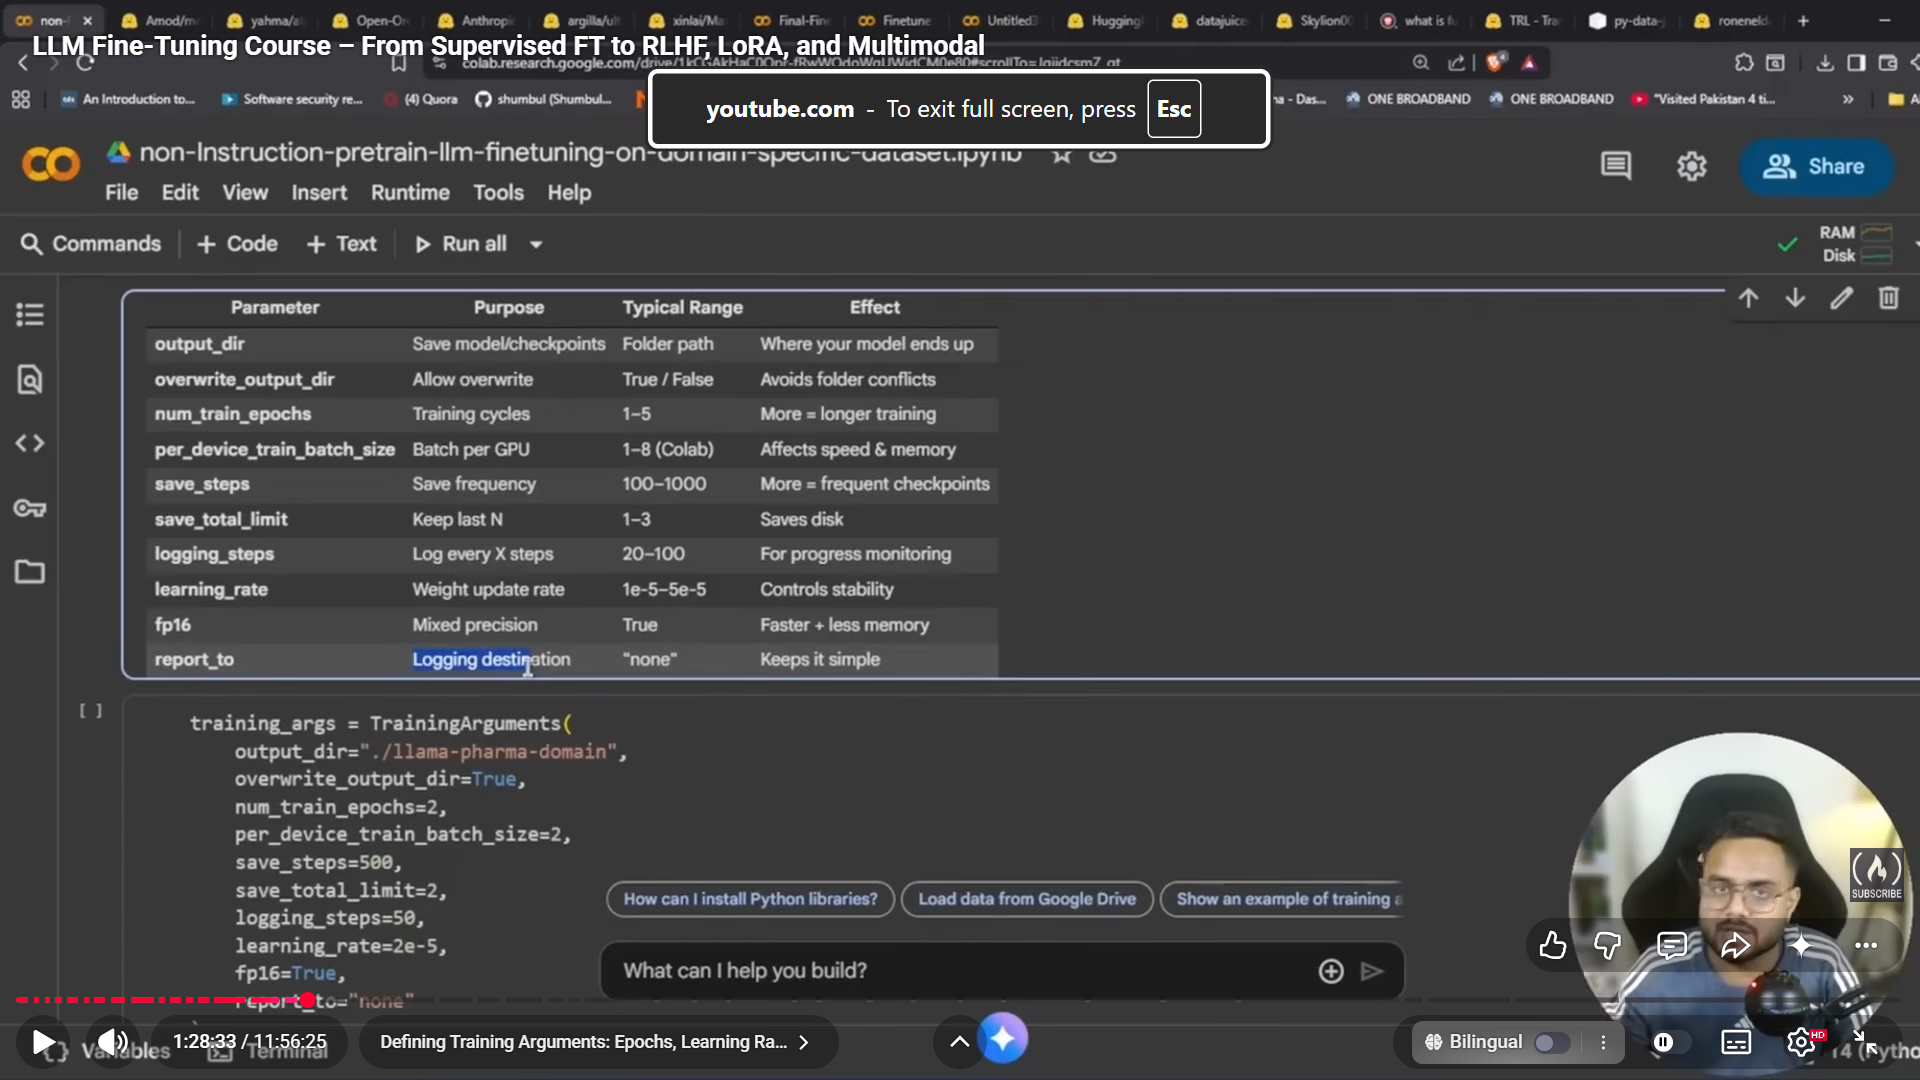

In [35]:

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none"
)

In [36]:

q_lora_model = get_peft_model(model, lora_config)

In [37]:
q_lora_model

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(32000, 2048)
        (layers): ModuleList(
          (0-21): 22 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear8bitLt(
                (base_layer): Linear8bitLt(in_features=2048, out_features=2048, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2048, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=2048, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): Li

In [38]:

training_args = TrainingArguments(
    output_dir="./llama-pharma-domain",
    num_train_epochs=2,
    per_device_train_batch_size=2,
    save_steps=500,
    save_total_limit=2,
    logging_steps=50,
    learning_rate=2e-5,
    fp16=True,
    report_to="none"
)

In [39]:
trainer = Trainer(
    model=q_lora_model,
    args=training_args,
    train_dataset=tokenized
)

In [40]:
trainer

In [41]:

trainer.train()

Step,Training Loss


TrainOutput(global_step=4, training_loss=10.933841705322266, metrics={'train_runtime': 10.5229, 'train_samples_per_second': 0.76, 'train_steps_per_second': 0.38, 'total_flos': 25451858755584.0, 'train_loss': 10.933841705322266, 'epoch': 2.0})

lora based techique

In [42]:

# import torch, gc
# gc.collect()
# torch.cuda.empty_cache()

In [43]:

model_path = "/content/llama-pharma-domain/checkpoint-4"

In [44]:

model

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 2048)
    (layers): ModuleList(
      (0-21): 22 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): lora.Linear8bitLt(
            (base_layer): Linear8bitLt(in_features=2048, out_features=2048, bias=False)
            (lora_dropout): ModuleDict(
              (default): Dropout(p=0.05, inplace=False)
            )
            (lora_A): ModuleDict(
              (default): Linear(in_features=2048, out_features=8, bias=False)
            )
            (lora_B): ModuleDict(
              (default): Linear(in_features=8, out_features=2048, bias=False)
            )
            (lora_embedding_A): ParameterDict()
            (lora_embedding_B): ParameterDict()
            (lora_magnitude_vector): ModuleDict()
          )
          (k_proj): Linear8bitLt(in_features=2048, out_features=256, bias=False)
          (v_proj): lora.Linear8bitLt(
            (base_layer): Linear8bitLt(in_featur

In [45]:

trained_model = AutoModelForCausalLM.from_pretrained(
    model_path,
    device_map="auto",
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/88 [00:00<?, ?it/s]

In [46]:
prompt = "Clinical trials have demonstrated that combining Atorvastatin with Ezetimibe"

In [47]:
device = "cuda" if torch.cuda.is_available() else "cpu"

inputs = tokenizer(prompt, return_tensors="pt").to(device)

In [48]:
outputs = trained_model.generate(
    **inputs,
    max_new_tokens=100,
    temperature=0.8,
    top_p=0.9,
    do_sample=True,
    repetition_penalty=1.1
)

[transformers] Both `max_new_tokens` (=100) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


In [51]:

print("\nModel Outputs:\n")
print(tokenizer.decode(outputs[0], skip_special_tokens=True))


Model Outputs:

Clinical trials have demonstrated that combining Atorvastatin with Ezetimibe can help prevent heart attacks and strokes in patients at high risk for these types of events.
Different versions of this drug are available and some have a higher or lower dose than the recommended dosage. Your doctor will determine what level of the drug is best for you.


that is teh non instructional finetuning of the model